In [119]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [120]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}') # import the attribute-relation file format
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c': # checks if the file is a synthetic dataset
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, distanceMetric='max'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if distanceMetric == 'median':
            arr += [np.median(x)]
        elif distanceMetric == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif distanceMetric == 'max':
            arr += [np.max(x)]
        elif distanceMetric == 'minMax':
            arr += [np.max(x) + x[1]]
        elif distanceMetric == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif distanceMetric == 'min':
            arr += [x[1]]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # returns index and distance of points
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, distanceMetric="max") # return arr of max values
        arr = np.log(arr)
        params = gamma.fit(arr) # fit params for gamma distribution
        posNeg4 = []
        spaceStep4 = np.linspace(0,.99,30) # threshold from 0 to .99, 30 samples
        for e in spaceStep4:
            newArr = arr > gamma.ppf(e,params[0],loc=params[1], scale=params[2]) # if arr value is outside threshold add to new array
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())]) # True positive rate, false positive rate

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)] # return the area under the curve

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="max")
    arr = np.log(arr)
    params = gamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    print(skew(arr),np.var(arr))
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.gamma, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()

0.7608725927104886 41 [0.7428975011936974, 0.7505869011618652, 0.7479806621040905, 0.7474136558968645, 0.7525067642845774, 0.7538098838134649, 0.7570726563743434, 0.756087856119688, 0.7563663854846409, 0.7554711125258633, 0.7558789590959731, 0.7545161547031672, 0.7555606398217412, 0.757132341238262, 0.7570229189877448, 0.757450660512494, 0.758524988063027, 0.757450660512494, 0.7573213433073371, 0.7559187490052522, 0.7553915327073053, 0.7557794843227758, 0.7575401878083716, 0.7572815533980582, 0.7571522361929015, 0.757371080693936, 0.7586244628362249, 0.7577490848320866, 0.7587040426547829, 0.7587239376094224, 0.7583757759032309, 0.7579181919465223, 0.7595993156135604, 0.759012414451695, 0.7576993474454877, 0.7587935699506604, 0.7606338532548146, 0.7593008912939678, 0.759768422727996, 0.7608725927104886, 0.7596092630908802, 0.7594699984084036, 0.7606636956867739, 0.7608725927104886, 0.7598480025465543, 0.7595495782269617, 0.758614515358905, 0.7581469839248768, 0.7586742002228236, 0.7578

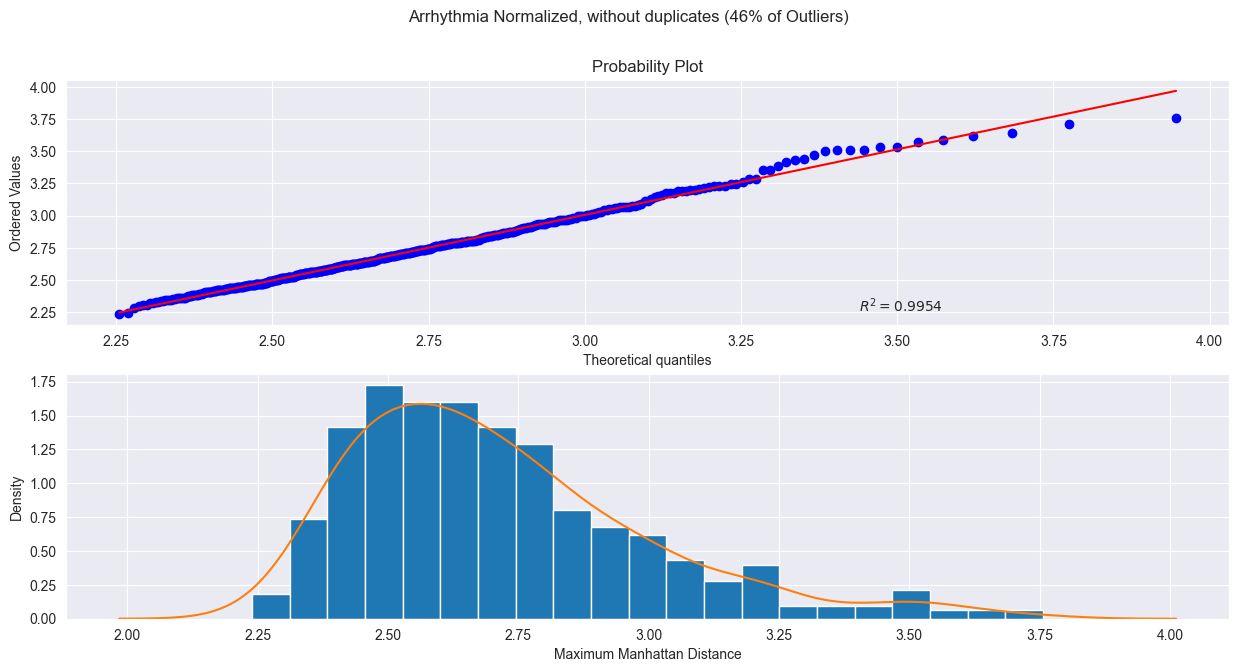

In [121]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,41,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

0.7400085034013606 6 [0.6462585034013606, 0.6952947845804989, 0.7341269841269842, 0.7194586167800453, 0.7400085034013606, 0.6926729024943311, 0.6831065759637188, 0.6780045351473923, 0.6541241496598639, 0.6494472789115646, 0.6465419501133787, 0.6430697278911565, 0.627905328798186, 0.610827664399093, 0.5994189342403629, 0.5930413832199546, 0.5796485260770976, 0.5845379818594105, 0.5764597505668935, 0.5729166666666667, 0.5707199546485261, 0.5705782312925171, 0.5715702947845805, 0.5668225623582767, 0.5649801587301587, 0.5622874149659863, 0.560515873015873, 0.5586734693877551, 0.5540674603174603, 0.5545634920634921, 0.5530045351473922, 0.5541383219954648, 0.5572562358276644, 0.5552012471655329, 0.5533588435374149, 0.5520833333333333, 0.5529336734693877, 0.5522959183673469, 0.5505243764172335, 0.5450680272108843, 0.5427295918367347, 0.5445719954648526, 0.5392573696145125, 0.5375566893424036, 0.5339427437641723, 0.5340844671201813, 0.5308956916099773, 0.5295493197278911, 0.5251558956916099, 0

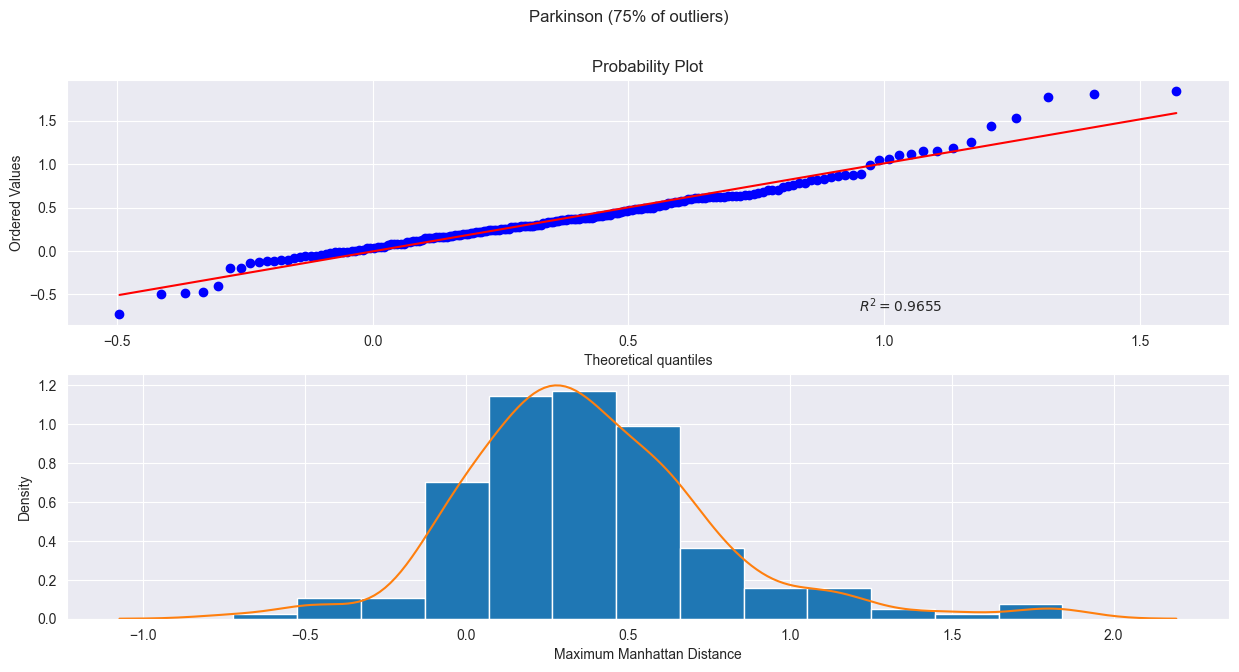

In [122]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,6,"Parkinson (75% of outliers)")

0.8456538461538462 5 [0.44630769230769235, 0.4600384615384615, 0.6227692307692306, 0.8456538461538462, 0.8385384615384616, 0.8245384615384617, 0.8132692307692307, 0.7991153846153847, 0.8033461538461538, 0.7967307692307692, 0.790653846153846, 0.7748076923076924, 0.7709615384615385, 0.7730769230769231, 0.7668846153846156, 0.7699230769230769, 0.7637307692307693, 0.7547307692307692, 0.7548076923076924, 0.7562692307692307, 0.7580384615384617, 0.7548461538461537, 0.7562692307692308, 0.7479615384615385, 0.7511923076923076, 0.7475384615384617, 0.7462307692307691, 0.743153846153846, 0.7401538461538462, 0.7405000000000002, 0.7339230769230769, 0.7397692307692307, 0.7390384615384616, 0.7378846153846154, 0.7331153846153846, 0.7331923076923077, 0.7327692307692308, 0.7352692307692308, 0.7390384615384615, 0.7308076923076925, 0.7303076923076924, 0.7301153846153848, 0.7228461538461539, 0.7220384615384614, 0.7221923076923078, 0.7160384615384616, 0.7118076923076924, 0.7156923076923077, 0.7123846153846154,

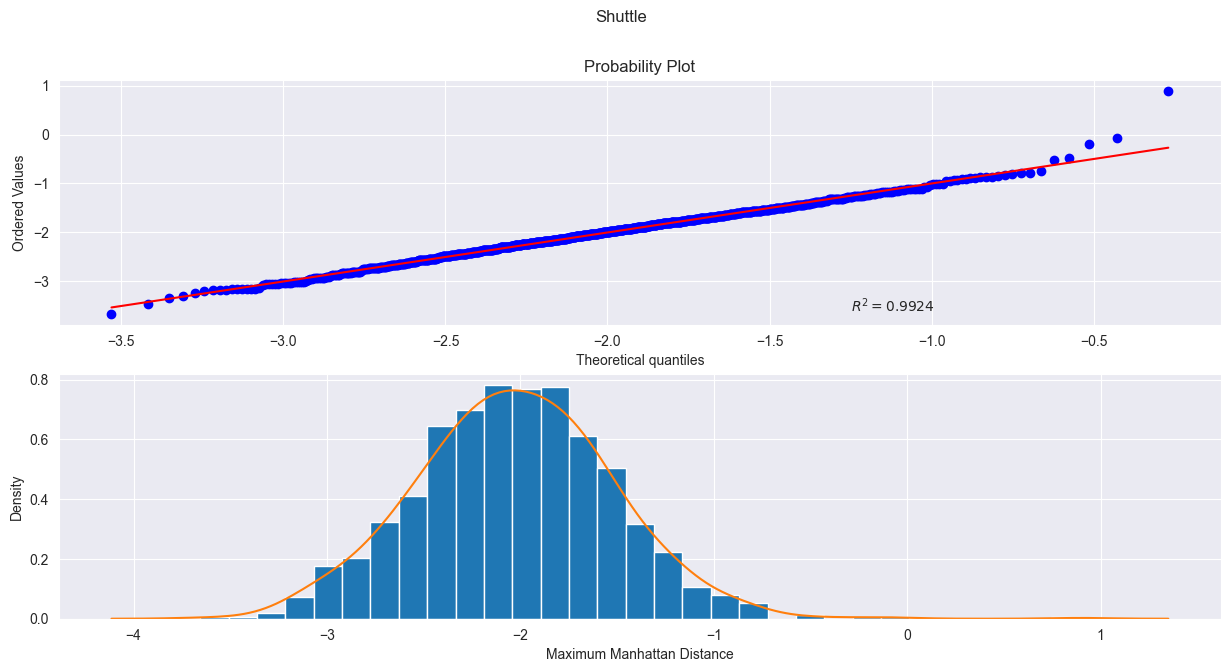

In [123]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,5,"Shuttle")

0.993661971830986 68 [0.8638497652582159, 0.9335680751173709, 0.8826291079812206, 0.9915492957746479, 0.984037558685446, 0.9830985915492957, 0.9809859154929577, 0.9788732394366197, 0.9809859154929577, 0.9577464788732395, 0.9774647887323943, 0.9725352112676057, 0.967136150234742, 0.9812206572769955, 0.9826291079812206, 0.983568075117371, 0.9873239436619718, 0.9873239436619718, 0.9830985915492959, 0.9868544600938968, 0.9868544600938967, 0.9884976525821595, 0.9884976525821596, 0.9884976525821595, 0.9868544600938967, 0.9868544600938967, 0.9873239436619717, 0.9873239436619718, 0.9873239436619717, 0.9915492957746478, 0.9915492957746479, 0.9906103286384977, 0.9906103286384976, 0.9906103286384976, 0.8873239436619719, 0.9842723004694836, 0.9786384976525822, 0.9812206572769954, 0.971830985915493, 0.9687793427230047, 0.9753521126760565, 0.9887323943661971, 0.9901408450704227, 0.9901408450704224, 0.9868544600938967, 0.9868544600938968, 0.9868544600938968, 0.9868544600938968, 0.9868544600938967, 0.

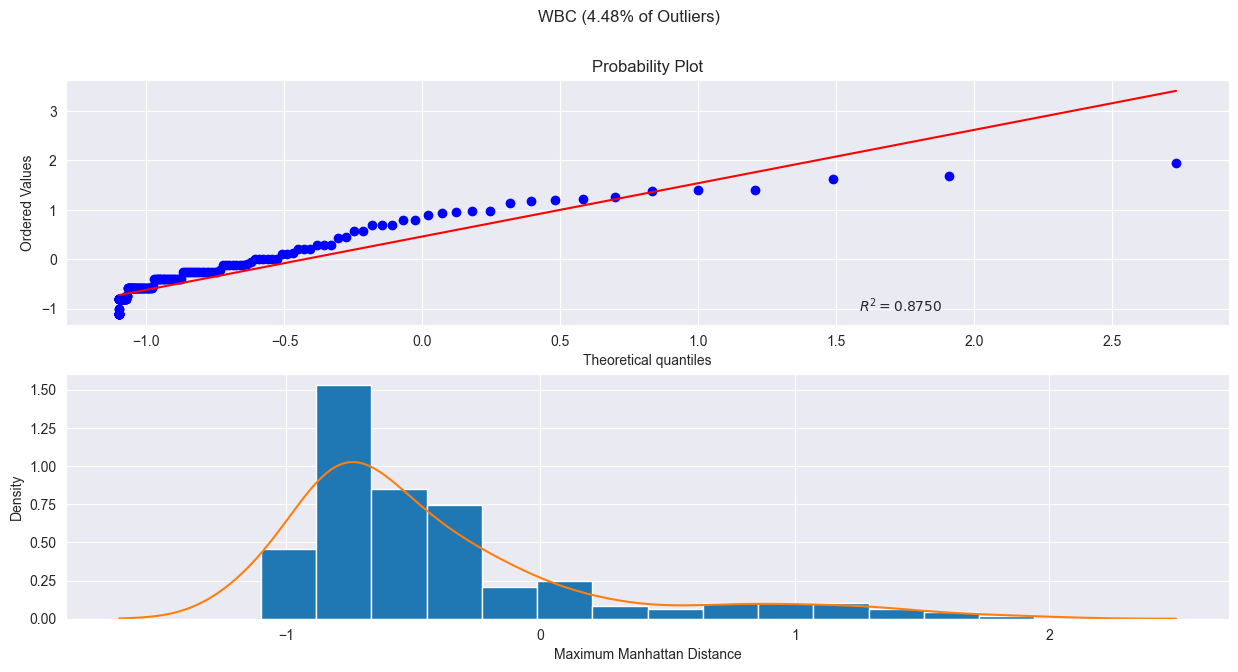

In [124]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,40,"WBC (4.48% of Outliers)")

0.650563127162793 42 [0.40846238625311937, 0.4751911409368144, 0.5079389574113586, 0.5306297873583582, 0.5462856507414751, 0.5703550844007509, 0.5842995614101222, 0.5901861038442111, 0.6066101356292549, 0.6166744257054756, 0.6209859932072287, 0.6228117625771821, 0.6268065681048847, 0.626799853552069, 0.6311393394576338, 0.6327529525184521, 0.6057815362519885, 0.6096599561975558, 0.6112813440037393, 0.6189757503336072, 0.6210485445676676, 0.610646170867228, 0.6174265734199832, 0.6475778605408586, 0.6226508489079545, 0.6222734203602205, 0.6262881339480251, 0.6188704378736588, 0.6135514518512375, 0.613106053181143, 0.6193736759373045, 0.6264226606026795, 0.6211589223920204, 0.6216817151182514, 0.5109023133872633, 0.6480641355237068, 0.245306880979486, 0.27985808498126524, 0.33155342710775704, 0.6501033569936898, 0.650563127162793, 0.650280526948681, 0.6499010958150195, 0.6499887383991375, 0.6492242217715486, 0.6502473075821202, 0.6493592196228919, 0.6494726602257221, 0.6495149501285423, 0

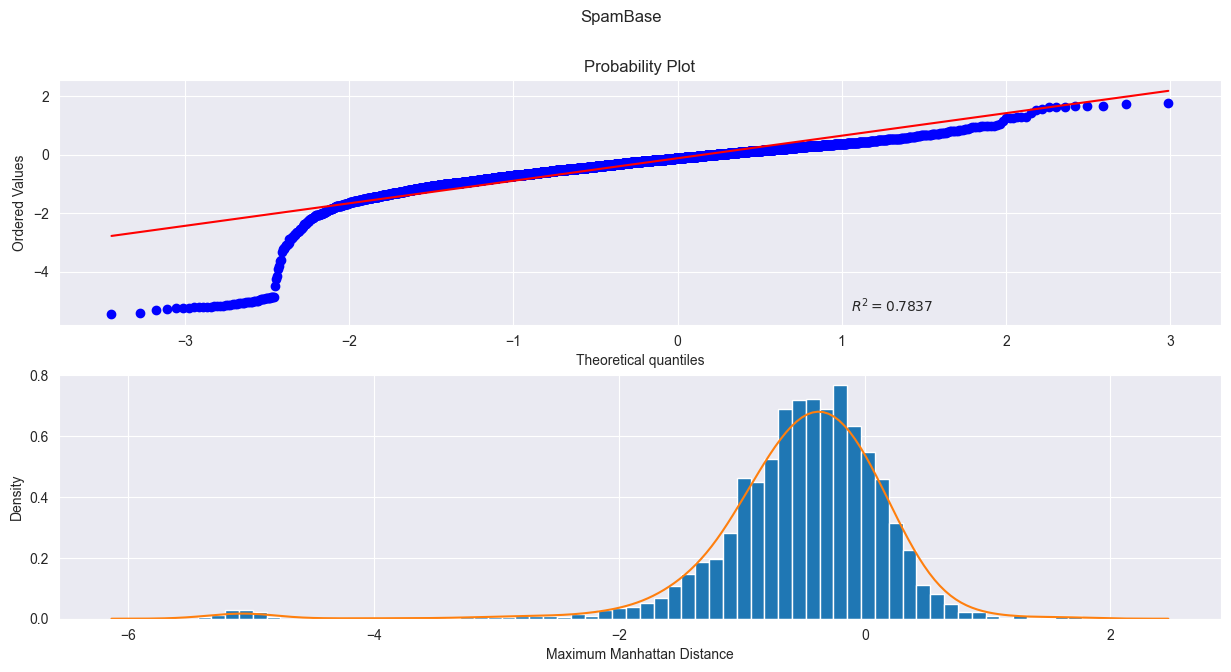

In [125]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
qqPlots(X,y,49,"SpamBase")

0.5321967028321825 19 [0.46244892207975197, 0.5065520642525011, 0.5186698605044385, 0.5238128786811327, 0.5216288572636326, 0.520642525010568, 0.5173312667324221, 0.5219811187825844, 0.5228969987318586, 0.5242355925038749, 0.5300831337184725, 0.5300831337184725, 0.5295899675919404, 0.5255741862758911, 0.5185289558968579, 0.5253628293645202, 0.5259264477948429, 0.5321967028321825, 0.5310694659715371, 0.5288149922502465, 0.5273354938706495, 0.5257855431872621, 0.5255037339721009, 0.525715090883472, 0.5258559954910527, 0.5266309708327462, 0.5249401155417782, 0.5238833309849232, 0.5181062420741158, 0.5232492602508101, 0.5204311680991969, 0.5176835282513738, 0.5214175003522614, 0.515640411441454, 0.5153586022262927, 0.5142313653656475, 0.5157813160490348, 0.5145131745808087, 0.5152881499225025, 0.515429054530083, 0.5118359870367759, 0.5126109623784697, 0.507186134986614, 0.5084542764548399, 0.5116246301254052, 0.5066225165562914, 0.5050021135691137, 0.5074679442017753, 0.5039453290122587, 0

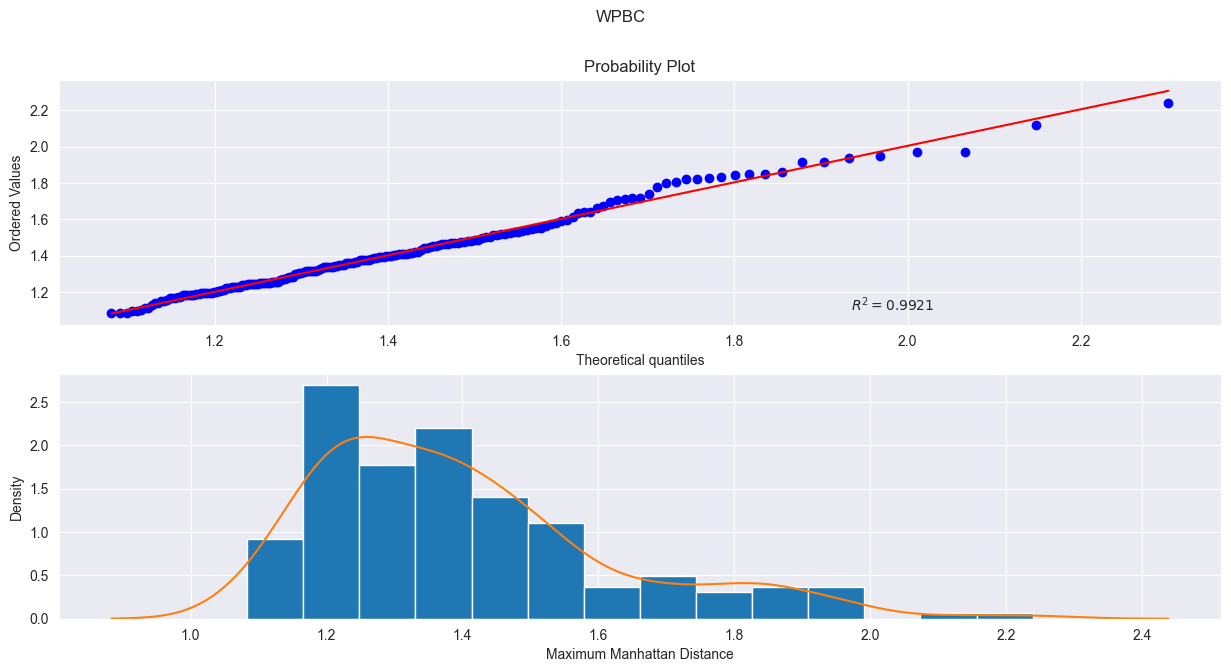

In [126]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"WPBC")

0.6990277777777778 69 [0.6115000000000002, 0.6234166666666667, 0.6202777777777778, 0.6214444444444445, 0.6204999999999999, 0.6308888888888887, 0.6306388888888889, 0.6372222222222224, 0.6449166666666668, 0.64575, 0.6487499999999999, 0.6537500000000002, 0.6538888888888889, 0.66075, 0.6628055555555555, 0.6639166666666668, 0.6632777777777777, 0.6603611111111113, 0.6602777777777776, 0.6600555555555557, 0.6621944444444444, 0.6641111111111112, 0.6608055555555555, 0.6563333333333333, 0.6646388888888888, 0.6623055555555556, 0.66225, 0.661888888888889, 0.6622777777777777, 0.6594166666666665, 0.659388888888889, 0.6570833333333331, 0.6612222222222223, 0.6628055555555554, 0.6633055555555555, 0.6620833333333332, 0.6635833333333334, 0.6653611111111111, 0.6664444444444444, 0.665611111111111, 0.6698333333333334, 0.6669722222222222, 0.6687222222222222, 0.6707500000000001, 0.6731944444444444, 0.6729166666666668, 0.6753333333333335, 0.6755000000000001, 0.6777777777777778, 0.6788055555555554, 0.68099999999

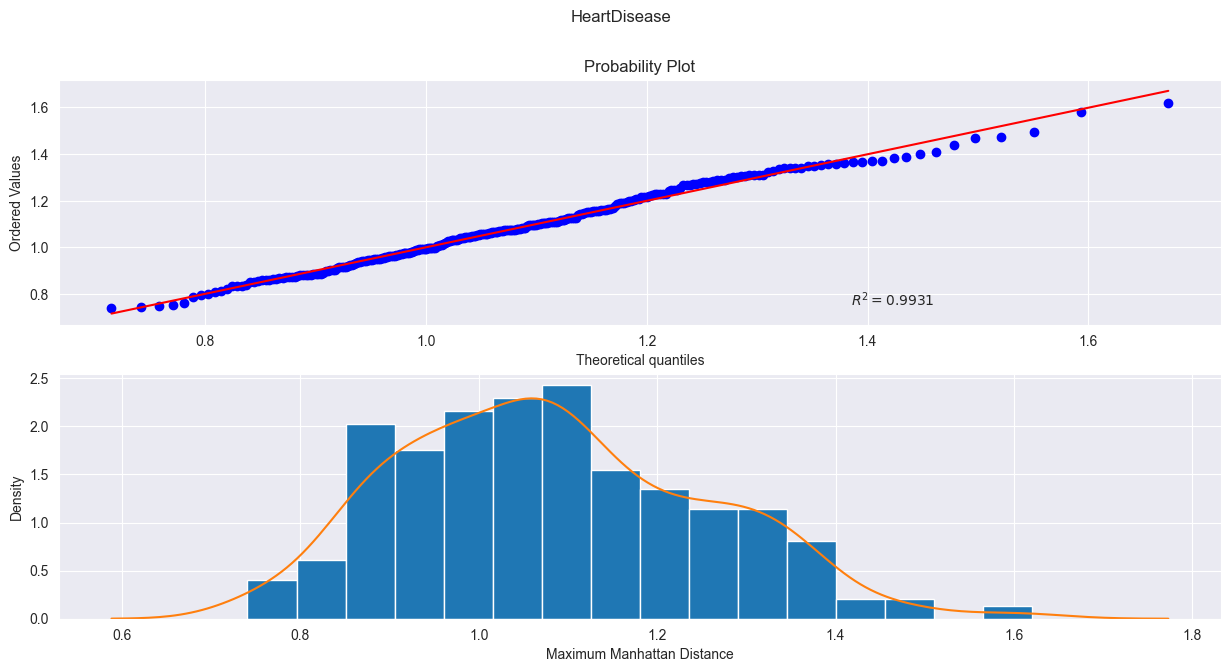

In [127]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,66,"HeartDisease")

In [129]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,2,"Glass")

ValueError: The data contains non-finite values.

0.785878300803674 25 [0.6274397244546498, 0.6176808266360505, 0.642939150401837, 0.6802525832376578, 0.6653272101033295, 0.6739380022962113, 0.7129735935706085, 0.711825487944891, 0.6991963260619978, 0.7290470723306544, 0.7290470723306544, 0.7313432835820894, 0.7261768082663606, 0.7284730195177956, 0.7399540757749713, 0.7554535017221585, 0.754305396096441, 0.7502870264064293, 0.7577497129735936, 0.761768082663605, 0.7652123995407577, 0.7761194029850745, 0.7732491389207808, 0.785878300803674, 0.7858783008036739, 0.7784156142365097, 0.7709529276693456, 0.7847301951779564, 0.7784156142365098, 0.7755453501722157, 0.772675086107922, 0.7772675086107922, 0.7789896670493686, 0.7709529276693455, 0.7795637198622273, 0.7698048220436281, 0.7698048220436281, 0.7784156142365097, 0.7853042479908151, 0.777841561423651, 0.7743972445464983, 0.762342135476464, 0.7577497129735935, 0.7646383467278989, 0.75947187141217, 0.7600459242250286, 0.753731343283582, 0.7497129735935705, 0.7433983926521239, 0.7485648

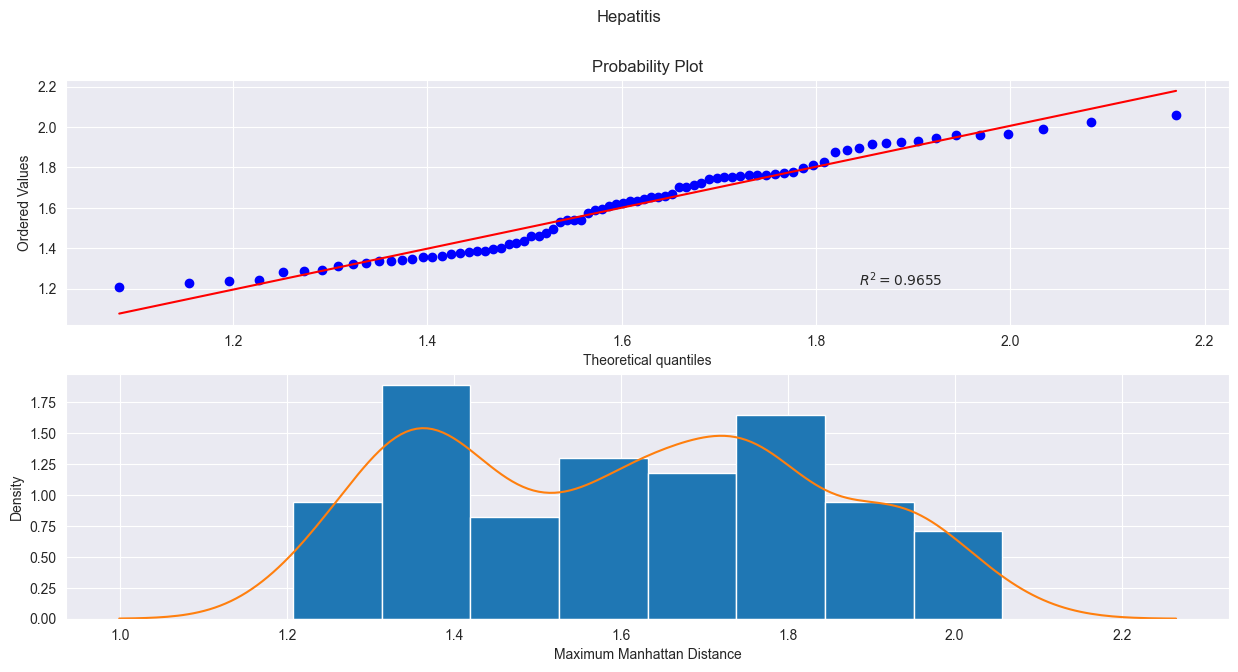

In [130]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,26,"Hepatitis")

0.7356716417910449 67 [0.677186567164179, 0.6928880597014925, 0.7069813432835822, 0.7080037313432836, 0.713294776119403, 0.7158358208955224, 0.717705223880597, 0.7210149253731342, 0.7203619402985074, 0.7211268656716417, 0.7205858208955225, 0.7217500000000001, 0.7214813432835822, 0.7220149253731343, 0.7239776119402985, 0.7210597014925373, 0.724820895522388, 0.7230932835820897, 0.7244514925373133, 0.7256268656716418, 0.725287313432836, 0.725973880597015, 0.7263880597014926, 0.7264514925373134, 0.7269328358208954, 0.7269365671641791, 0.7283656716417911, 0.7284179104477612, 0.727686567164179, 0.7292201492537314, 0.7286679104477612, 0.7289029850746271, 0.7282350746268658, 0.7286679104477612, 0.7288768656716419, 0.7275970149253732, 0.7280410447761194, 0.7273694029850747, 0.7287537313432837, 0.7303507462686567, 0.7302313432835822, 0.7302388059701491, 0.731115671641791, 0.731578358208955, 0.730988805970149, 0.7296380597014924, 0.7314328358208956, 0.7304738805970148, 0.7312164179104477, 0.73191

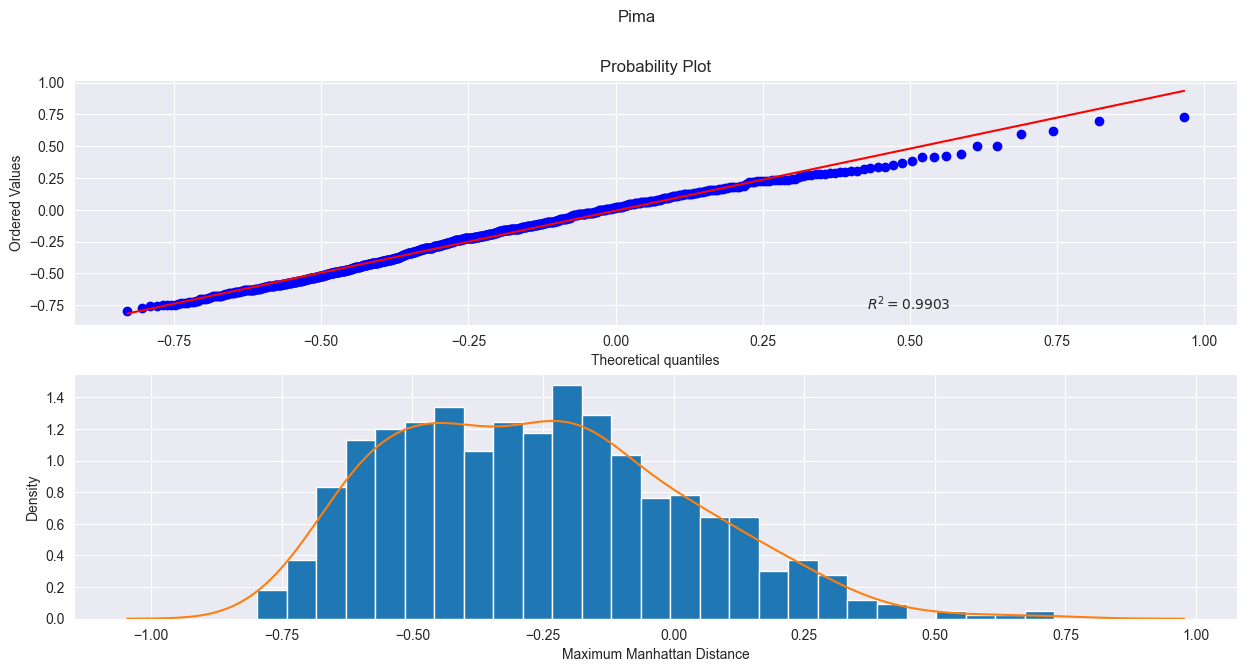

In [131]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,69,"Pima")

0.9874136880584891 13 [0.9281478472786353, 0.9764444557270512, 0.9777695978878959, 0.9815216287571079, 0.9813566206336312, 0.9845628554021121, 0.9853650487408611, 0.9859768480909828, 0.9855808285946385, 0.9859260763606823, 0.9855224411047928, 0.9874136880584891, 0.9867181153533714, 0.9866216490658, 0.9865074126726238, 0.9869618196588139, 0.9863144800974817, 0.9856595247766043, 0.9854082047116166, 0.9854691307879773, 0.9838139723801788, 0.9815749390739237, 0.9818287977254266, 0.9802294882209587, 0.9802954914703492, 0.9812652315190902, 0.9808742891957759, 0.9809022136474411, 0.9789297319252639, 0.9787571080422423, 0.9782798537774167, 0.9783407798537775, 0.9772187246141348, 0.9755737205523967, 0.9757438058489034, 0.9758123476848093, 0.9753604792851341, 0.975533103168156, 0.9750761575954509, 0.9752437043054428, 0.9752208570268073, 0.9751269293257513, 0.9756321080422422, 0.9754924857839157, 0.9757768074735987, 0.9755762591389114, 0.9754264825345248, 0.9752970146222583, 0.9759595857026806, 0

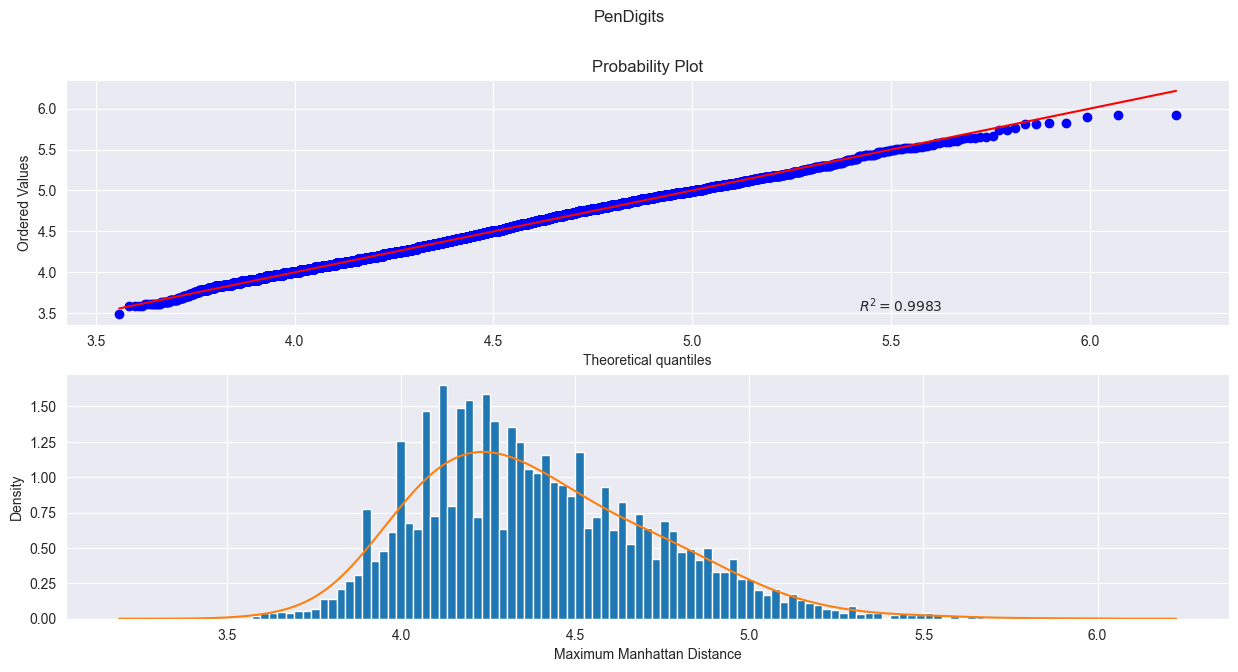

In [132]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
qqPlots(X,y,12,"PenDigits")

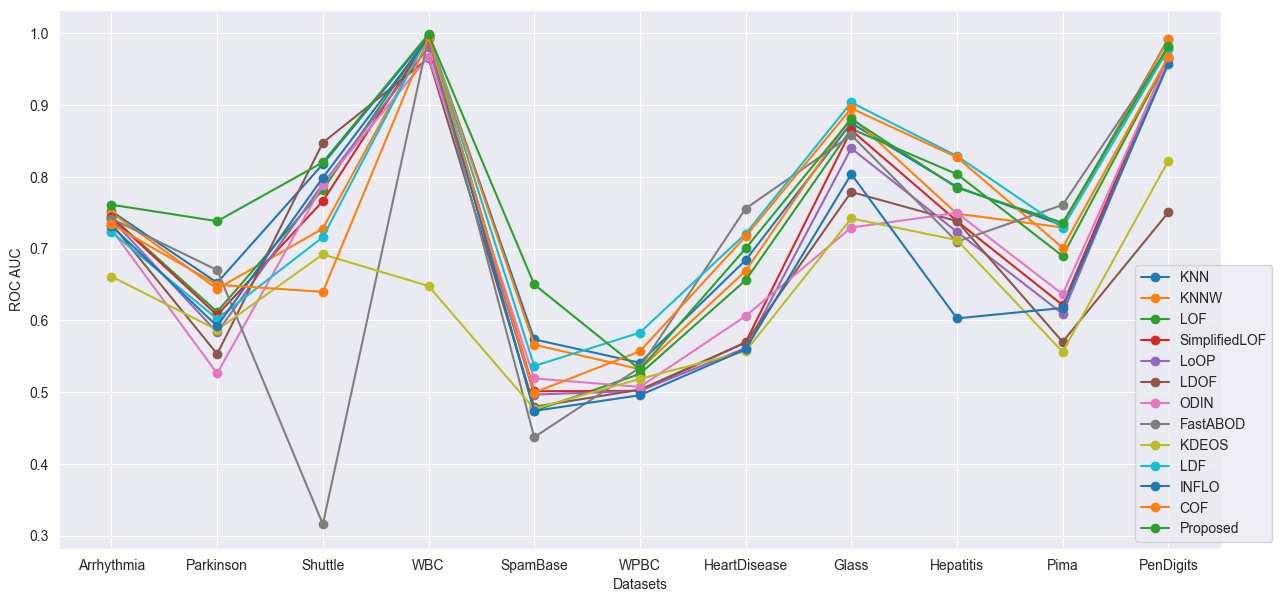

In [108]:
valuesperSet = [[0.752,0.75008,0.74421,0.74339,0.74111,0.73452,0.72669,0.74176,0.66101,0.72286,0.73154,0.73385,0.761081489734203],
[0.65235,0.64399,0.61196,0.60728,0.58312,0.55315,0.52608,0.66993,0.58673,0.60218,0.59198,0.64966,0.738166099773242],
[0.81762,0.72785,0.78208,0.76608,0.78992,0.84754,0.789,0.316,0.69192,0.71585,0.79885,0.63969,0.820153846153846],
[0.99718,0.99718,0.99671,0.9939,0.98028,0.96526,0.96737,0.99484,0.64789,0.99718,0.9939,0.99437,0.998591549295774],
[0.57347,0.56618,0.47384,0.50119,0.49658,0.4796,0.5191,0.43721,0.47667,0.53641,0.47381,0.49945,0.650009471053444],
[0.5409,0.53191,0.52543,0.50183,0.50183,0.50345,0.50726,0.53417,0.51853,0.58292,0.4957,0.55686,0.531562632098069],
[0.68383,0.66883,0.65583,0.56933,0.56139,0.56906,0.60592,0.75567,0.55694,0.72056,0.55967,0.71683,0.700166666666666],
[0.8748,0.8832,0.86667,0.86504,0.83957,0.77886,0.72927,0.85799,0.74201,0.90352,0.80379,0.89539,0.880487804878048],
[0.78588,0.74856,0.80367,0.73823,0.72331,0.73823,0.74971,0.70953,0.71183,0.82893,0.60276,0.82721,0.784730195177956],
[0.73224,0.72944,0.68955,0.62131,0.60922,0.57004,0.63637,0.76081,0.55621,0.72888,0.61728,0.70121,0.735914179104477],
[0.99212,0.9916,0.96581,0.9668,0.96231,0.75034,0.96432,0.97979,0.82214,0.97791,0.95712,0.96695,0.982605605199025],
]
datasets = ['Arrhythmia','Parkinson','Shuttle','WBC','SpamBase','WPBC','HeartDisease','Glass','Hepatitis','Pima','PenDigits']

algo = ['KNN','KNNW','LOF','SimplifiedLOF','LoOP','LDOF','ODIN','FastABOD','KDEOS','LDF','INFLO','COF','Proposed']

plt.plot(datasets,valuesperSet,marker='o')
plt.ylabel("ROC AUC")
plt.xlabel("Datasets")
plt.legend(algo,loc=4,bbox_to_anchor=(1.05,0))
plt.show()